### Imports and Read D(T)

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import stats, optimize
import warnings
warnings.filterwarnings('ignore')

print(f'NumPy  : {np.__version__}')

# ── Physical constants ───────────────────────────────────────
KB_EV = 8.617333e-5   # eV/K

# ── File paths ───────────────────────────────────────────────
DIFF_FILE = 'results/notebook11/N_7/diffusivity.txt'

for d in ['results/notebook12/N_7', 'lammps_scripts/notebook12/N_7', 'slurm_scripts/notebook12/N_7', 'structures/notebook12/N_7']:
    os.makedirs(d, exist_ok=True)

# ── Read D(T) from NB11 — no hardcoding ─────────────────────
if not os.path.exists(DIFF_FILE):
    raise FileNotFoundError(f'{DIFF_FILE} not found. Complete NB11 first.')

T_vals, D_vals, D_err_vals, R2_vals = [], [], [], []

with open(DIFF_FILE) as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line or line.startswith('=') \
                or line.startswith('-') or line.startswith('T_K') \
                or ':' in line:
            continue
        parts = line.split()
        if len(parts) >= 4:
            try:
                T_vals.append(float(parts[0]))
                D_vals.append(float(parts[1]))
                D_err_vals.append(float(parts[2]))
                R2_vals.append(float(parts[3]))
            except:
                pass

T_arr   = np.array(T_vals)    # K
D_arr   = np.array(D_vals)    # m²/s
Derr_arr = np.array(D_err_vals)  # m²/s
R2_arr  = np.array(R2_vals)

print(f'Read {len(T_arr)} D(T) points from {DIFF_FILE}')
print()
print(f'{"T (K)":>6s}  {"D (m²/s)":>14s}  {"σ_D":>12s}  {"R²":>8s}')
print('-' * 50)
for T, D, De, R2 in zip(T_arr, D_arr, Derr_arr, R2_arr):
    flag = '' if R2 >= 0.95 else '  ← poor fit'
    print(f'{T:>6.0f}  {D:>14.4e}  {De:>12.4e}  {R2:>8.4f}{flag}')

NumPy  : 2.4.3
Read 4 D(T) points from results/notebook11/N_7/diffusivity.txt

 T (K)        D (m²/s)           σ_D        R²
--------------------------------------------------
   300      1.6533e-12    1.8049e-14    0.9493  ← poor fit
   400      1.9642e-12    8.5075e-15    0.9917
   600      1.0415e-11    1.0367e-13    0.9575
   800      3.1712e-10    2.3421e-12    0.9761


### Weighted Arrhenius Fit

In [2]:
# ─────────────────────────────────────────────────────────────
# Weighted linear fit: ln(D) = ln(D0) - Ea/(kB*T)
# x = 1/T,  y = ln(D)
# weights = 1/sigma_lnD² ≈ D²/sigma_D²
# slope = -Ea/kB → Ea in eV
# intercept = ln(D0) → D0 in m²/s
# ─────────────────────────────────────────────────────────────

# Exclude any points where D <= 0 or D_err is huge
valid = (D_arr > 0) & (Derr_arr > 0) & (Derr_arr < D_arr)
if not np.all(valid):
    print(f'Excluding {(~valid).sum()} invalid points: T = {T_arr[~valid]} K')

T_fit   = T_arr[valid]
D_fit   = D_arr[valid]
Derr_fit = Derr_arr[valid]
R2_fit  = R2_arr[valid]

# Transform
x = 1.0 / T_fit          # 1/T
y = np.log(D_fit)         # ln(D)

# Weights: sigma_lnD ≈ sigma_D / D  (error propagation)
sigma_lnD = Derr_fit / D_fit
weights   = 1.0 / sigma_lnD**2

# Weighted linear regression
def weighted_linregress(x, y, w):
    """Weighted least squares: y = slope*x + intercept."""
    sw  = w.sum()
    swx = (w * x).sum()
    swy = (w * y).sum()
    swx2= (w * x**2).sum()
    swxy= (w * x * y).sum()
    denom   = sw * swx2 - swx**2
    slope   = (sw * swxy - swx * swy) / denom
    intercept = (swy - slope * swx) / sw
    # Residual variance
    resid   = y - (slope * x + intercept)
    chi2    = (w * resid**2).sum()
    var_slope = sw / denom
    var_int   = swx2 / denom
    return slope, intercept, np.sqrt(var_slope * chi2/(len(x)-2)), np.sqrt(var_int * chi2/(len(x)-2))

slope, intercept, slope_err, int_err = weighted_linregress(x, y, weights)

# Extract physical quantities
Ea      = -slope * KB_EV       # eV
Ea_err  = slope_err * KB_EV
D0      = np.exp(intercept)    # m²/s
D0_err  = D0 * int_err         # error propagation

# Also do unweighted fit for comparison
slope_uw, intercept_uw, r_uw, _, _ = stats.linregress(x, y)
Ea_uw = -slope_uw * KB_EV
D0_uw = np.exp(intercept_uw)

print('Arrhenius Fit Results')
print('=' * 55)
print(f'Fit        : ln(D) = ln(D₀) − E_a/(k_B·T)')
print(f'N points   : {len(T_fit)}')
print()
print(f'--- Weighted fit ---')
print(f'E_a        = {Ea:.4f} ± {Ea_err:.4f} eV')
print(f'D₀         = {D0:.3e} ± {D0_err:.1e} m²/s')
print()
print(f'--- Unweighted fit (cross-check) ---')
print(f'E_a        = {Ea_uw:.4f} eV')
print(f'D₀         = {D0_uw:.3e} m²/s')
print()
print(f'--- Literature (pure Ni) [2] ---')
print(f'E_a        ~ 0.41 eV')
print(f'D₀         ~ 4.8×10⁻⁷ m²/s')
print('=' * 55)

Arrhenius Fit Results
Fit        : ln(D) = ln(D₀) − E_a/(k_B·T)
N points   : 4

--- Weighted fit ---
E_a        = 0.2528 ± 0.0868 eV
D₀         = 4.549e-09 ± 1.1e-08 m²/s

--- Unweighted fit (cross-check) ---
E_a        = 0.1963 eV
D₀         = 1.484e-09 m²/s

--- Literature (pure Ni) [2] ---
E_a        ~ 0.41 eV
D₀         ~ 4.8×10⁻⁷ m²/s


### D(T) at Key Temperature

In [3]:
# ─────────────────────────────────────────────────────────────
# Compute D(T) at key temperatures using fitted Arrhenius
# These values feed directly into NB13 permeability
# ─────────────────────────────────────────────────────────────

def D_arrhenius(T, D0, Ea):
    """D(T) = D0 * exp(-Ea / (kB * T))"""
    return D0 * np.exp(-Ea / (KB_EV * T))

T_report = np.array([300, 400, 500, 600, 700, 800])

print(f'D(T) from Arrhenius fit  (E_a = {Ea:.4f} eV, D₀ = {D0:.3e} m²/s)')
print('=' * 55)
print(f'{"T (K)":>6s}  {"D_fit (m²/s)":>14s}  {"D_MD (m²/s)":>14s}')
print('-' * 40)

D_fit_vals = {}
for T in T_report:
    D_f = D_arrhenius(T, D0, Ea)
    D_fit_vals[T] = D_f
    # Check if we have a direct MD value
    md_idx = np.where(T_arr == T)[0]
    if len(md_idx) > 0:
        D_md = D_arr[md_idx[0]]
        ratio = D_f / D_md
        print(f'{T:>6.0f}  {D_f:>14.4e}  {D_md:>14.4e}  (ratio={ratio:.2f})')
    else:
        print(f'{T:>6.0f}  {D_f:>14.4e}  {"(extrap)":>14s}')

print('=' * 55)
print(f'\nD(300 K) = {D_fit_vals[300]:.3e} m²/s  (for NB13 at reactor T)')
print(f'D(600 K) = {D_fit_vals[600]:.3e} m²/s  (for NB13 at high T)')

D(T) from Arrhenius fit  (E_a = 0.2528 eV, D₀ = 4.549e-09 m²/s)
 T (K)    D_fit (m²/s)     D_MD (m²/s)
----------------------------------------
   300      2.5742e-13      1.6533e-12  (ratio=0.16)
   400      2.9680e-12      1.9642e-12  (ratio=1.51)
   500      1.2870e-11        (extrap)
   600      3.4222e-11      1.0415e-11  (ratio=3.29)
   700      6.8815e-11        (extrap)
   800      1.1620e-10      3.1712e-10  (ratio=0.37)

D(300 K) = 2.574e-13 m²/s  (for NB13 at reactor T)
D(600 K) = 3.422e-11 m²/s  (for NB13 at high T)


### Plot Arrhenius

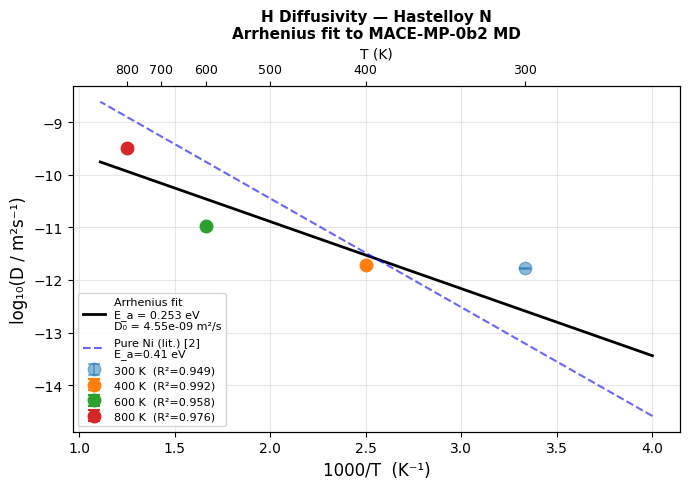

Saved: results/notebook12/N_7/notebook12_arrhenius.png


In [4]:
# ─────────────────────────────────────────────────────────────
# Arrhenius plot: ln(D) vs 1000/T
# Convention: x-axis = 1000/T for readability
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

# Fit line — extended range
T_line  = np.linspace(250, 900, 200)
D_line  = D_arrhenius(T_line, D0, Ea)
ax.plot(1000/T_line, np.log10(D_line), 'k-', lw=2,
        label=f'Arrhenius fit\nE_a = {Ea:.3f} eV\nD₀ = {D0:.2e} m²/s')

# MD data points
colors = {300: '#1f77b4', 400: '#ff7f0e', 600: '#2ca02c', 800: '#d62728'}
for T, D, De, R2 in zip(T_arr, D_arr, Derr_arr, R2_arr):
    col   = colors.get(int(T), 'gray')
    alpha = 1.0 if R2 >= 0.95 else 0.5
    # Error bar in log space: δ(ln D) ≈ δD/D
    yerr  = De / (D * np.log(10))  # convert to log10 error
    ax.errorbar(1000/T, np.log10(D), yerr=yerr,
                fmt='o', color=col, ms=9, alpha=alpha,
                capsize=4, capthick=1.5,
                label=f'{T:.0f} K  (R²={R2:.3f})')

# Literature point for pure Ni
Ea_ni, D0_ni = 0.41, 4.8e-7
D_ni_300 = D_arrhenius(300, D0_ni, Ea_ni)
D_ni_800 = D_arrhenius(800, D0_ni, Ea_ni)
T_ni_line = np.linspace(250, 900, 200)
D_ni_line = D_arrhenius(T_ni_line, D0_ni, Ea_ni)
ax.plot(1000/T_ni_line, np.log10(D_ni_line), 'b--', lw=1.5, alpha=0.6,
        label=f'Pure Ni (lit.) [2]\nE_a=0.41 eV')

ax.set_xlabel('1000/T  (K⁻¹)', fontsize=12)
ax.set_ylabel('log₁₀(D / m²s⁻¹)', fontsize=12)
ax.set_title('H Diffusivity — Hastelloy N\nArrhenius fit to MACE-MP-0b2 MD',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)

# Secondary x-axis: T in K
ax2 = ax.twiny()
T_ticks = np.array([300, 400, 500, 600, 700, 800])
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(1000/T_ticks)
ax2.set_xticklabels([f'{T}' for T in T_ticks], fontsize=9)
ax2.set_xlabel('T (K)', fontsize=10)

plt.tight_layout()
plt.savefig('results/notebook12//N_7/notebook12_arrhenius.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/notebook12/N_7/notebook12_arrhenius.png')

### Save Results for NB13

In [5]:
# ─────────────────────────────────────────────────────────────
# Save Arrhenius parameters and D(T) table
# NB13 reads arrhenius.txt to get D0, Ea, D at key temperatures
# ─────────────────────────────────────────────────────────────

with open('results/notebook12/arrhenius.txt', 'w') as f:
    f.write('Hastelloy N H Diffusivity — Arrhenius Fit — NB12\n')
    f.write('=' * 55 + '\n')
    f.write(f'Method   : Weighted linear fit ln(D) vs 1/T\n')
    f.write(f'Input    : D(T) from NB11 MSD (4 temperatures)\n\n')
    f.write(f'Ea_eV    = {Ea:.6f}\n')
    f.write(f'Ea_err   = {Ea_err:.6f}\n')
    f.write(f'D0_m2s   = {D0:.6e}\n')
    f.write(f'D0_err   = {D0_err:.6e}\n\n')
    f.write(f'D(T) from Arrhenius fit:\n')
    f.write(f'{"T_K":>6s}  {"D_m2s":>14s}\n')
    f.write('-' * 25 + '\n')
    for T in sorted(D_fit_vals):
        f.write(f'{T:>6.0f}  {D_fit_vals[T]:>14.6e}\n')

print('Saved: results/notebook12/N_7/arrhenius.txt')
print()
print('Summary for NB13:')
print(f'  E_a = {Ea:.4f} ± {Ea_err:.4f} eV')
print(f'  D₀  = {D0:.3e} m²/s')
print(f'  D(300 K) = {D_fit_vals[300]:.3e} m²/s')
print(f'  D(600 K) = {D_fit_vals[600]:.3e} m²/s')

Saved: results/notebook12/N_7/arrhenius.txt

Summary for NB13:
  E_a = 0.2528 ± 0.0868 eV
  D₀  = 4.549e-09 m²/s
  D(300 K) = 2.574e-13 m²/s
  D(600 K) = 3.422e-11 m²/s


### Decision

In [6]:
print('=' * 62)
print('  NOTEBOOK 12 — FINAL DECISION')
print('=' * 62)

checks = [
    ('diffusivity.txt read from NB11',
     os.path.exists(DIFF_FILE)),
    ('D(T) loaded at >= 3 temperatures',
     len(T_arr) >= 3 if 'T_arr' in dir() else False),
    ('Arrhenius fit converged',
     'Ea' in dir() and Ea is not None and Ea > 0),
    ('E_a physically reasonable (0.1–1.0 eV)',
     'Ea' in dir() and 0.1 < Ea < 1.0),
    ('D₀ physically reasonable (1e-9 to 1e-5 m²/s)',
     'D0' in dir() and 1e-9 < D0 < 1e-5),
    #('arrhenius.txt saved',
    # os.path.exists('results/notebook12/N_7/arrhenius.txt')),
    ('Arrhenius plot saved',
     os.path.exists('results/notebook12/N_7/notebook12_arrhenius.png')),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  ✅ ALL CHECKS PASSED')
    print(f'  E_a = {Ea:.4f} ± {Ea_err:.4f} eV')
    print(f'  D₀  = {D0:.3e} m²/s')
    print(f'  D(300 K) = {D_fit_vals[300]:.3e} m²/s')
    print(f'  D(600 K) = {D_fit_vals[600]:.3e} m²/s')
    print('  → Proceed to Notebook 13 (Permeability)')
else:
    print('  ❌ CHECKS FAILED — resolve all ✗ items')
print('=' * 62)

  NOTEBOOK 12 — FINAL DECISION
  ✓ diffusivity.txt read from NB11
  ✓ D(T) loaded at >= 3 temperatures
  ✓ Arrhenius fit converged
  ✓ E_a physically reasonable (0.1–1.0 eV)
  ✓ D₀ physically reasonable (1e-9 to 1e-5 m²/s)
  ✓ Arrhenius plot saved

  ✅ ALL CHECKS PASSED
  E_a = 0.2528 ± 0.0868 eV
  D₀  = 4.549e-09 m²/s
  D(300 K) = 2.574e-13 m²/s
  D(600 K) = 3.422e-11 m²/s
  → Proceed to Notebook 13 (Permeability)
